In [2]:
pip install pandas numpy scikit-learn yfinance matplotlib tensorflow

In [13]:
import yfinance as yf
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


ticker = "AAPL"
data = yf.download(ticker, start="2020-01-01", end="2026-01-01" , auto_adjust=True)

print("\n",data)
data['MA5'] = data['Close'].rolling(5).mean()
data['MA20'] = data['Close'].rolling(20).mean()

data['Return'] = data['Close'].pct_change()

data['Volatility'] = (
    data['High'] - data['Low']
) / data['Close']


data['Target'] = data['Close'].shift(-1)

features = [
    'Open',
    'High',
    'Low',
    'Close',
    'Volume',
    'MA5',
    'MA20',
    'Return',
    'Volatility'
]

data = data.dropna()

X = data[features]
y = data['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)


[*********************100%***********************]  1 of 1 completed


 Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2020-01-02   72.333885   72.394093   71.091191   71.344062  135480400
2020-01-03   71.630638   72.389257   71.406666   71.563205  146322800
2020-01-06   72.201401   72.239935   70.503539   70.754006  118387200
2020-01-07   71.861870   72.466353   71.642712   72.211072  108872000
2020-01-08   73.017838   73.318877   71.565621   71.565621  132079200
...                ...         ...         ...         ...        ...
2025-12-24  273.302216  274.919206  271.695216  271.834940   17910600
2025-12-26  272.893005  274.859353  272.353998  273.651606   21521800
2025-12-29  273.252350  273.851213  271.844961  272.184327   23715200
2025-12-30  272.573547  273.571693  271.775043  272.304059   22139600
2025-12-31  271.355835  273.172467  271.246054  272.553622   27293600

[1508 rows x 5 co

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 2.7465567255001035
RMSE: 4.151858333654873
R²: 0.9719076028939444


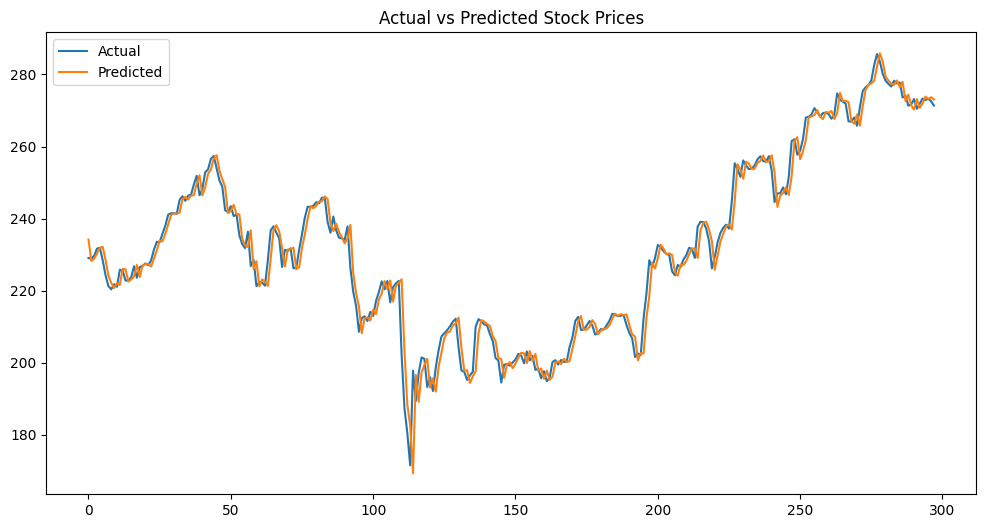

In [15]:
#visualizing the predictions and and the actual prices! and they are pretty close.

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual")
plt.plot(predictions, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Stock Prices")
plt.show()

In [ ]:
latest_data = X.iloc[-1:]
next_close = model.predict(latest_data)

print("Predicted next day's closing price:", next_close[0])

Price             Open        High         Low       Close    Volume  \
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL   
Date                                                                   
2025-12-30  272.304059  273.571693  271.775043  272.573547  22139600   

Price              MA5        MA20    Return Volatility  
Ticker                                                   
Date                                                     
2025-12-30  272.775208  275.676814 -0.002484   0.006591  
Predicted next day's closing price: 273.0470471240975
